# <center> **Data Analysis on Filipino Family Income and Expenditure**
#### <center> Analysts: Cristina Gail Rodelas and Nicole Patrice Torrero, BSIT-3A
#### <center> An output for the course ITD: Data Mining
***

<div style="text-align: justify">
  The dataset comes from the <b>Family Income and Expenditure Survey (FIES)</b> conducted by the Philippine Statistics Authority (PSA). This national survey is carried out every three years to collect information on family income and expenditures, including levels of consumption by item of expenditure, sources of income in cash, and other related data that influence income and spending patterns in the Philippines.
  <br><br>
  The dataset contains more than 40,000 observations and 60 variables, primarily comprising the household income and expenditures of specific households. For this analysis, we will be using Python’s <b>pandas</b>, <b>seaborn</b>, <b>matplotlib</b>, and <b>numpy</b>, libraries.
</div>

In [1]:
import numpy as np
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings 
warnings.filterwarnings('ignore')

In [2]:
income = pd.read_csv("datasets\\Family Income and Expenditure.csv")
income

,Total Household Income,Region,Total Food Expenditure,Main Source of Income,Agricultural Household indicator,Bread and Cereals Expenditure,Total Rice Expenditure,Meat Expenditure,Total Fish and marine products Expenditure,Fruit Expenditure,...,Number of Refrigerator/Freezer,Number of Washing Machine,Number of Airconditioner,"Number of Car, Jeep, Van",Number of Landline/wireless telephones,Number of Cellular phone,Number of Personal Computer,Number of Stove with Oven/Gas Range,Number of Motorized Banca,Number of Motorcycle/Tricycle
0,480332,CAR,117848,Wage/Salaries,0,42140,38300,24676,16806,3325,...,1,1,0,0,0,2,1,0,0,1
1,198235,CAR,67766,Wage/Salaries,0,17329,13008,17434,11073,2035,...,0,1,0,0,0,3,1,0,0,2
2,82785,CAR,61609,Wage/Salaries,1,34182,32001,7783,2590,1730,...,0,0,0,0,0,0,0,0,0,0
3,107589,CAR,78189,Wage/Salaries,0,34030,28659,10914,10812,690,...,0,0,0,0,0,1,0,0,0,0
4,189322,CAR,94625,Wage/Salaries,0,34820,30167,18391,11309,1395,...,1,0,0,0,0,3,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41539,119773,XII - SOCCSKSARGEN,44875,Enterpreneurial Activities,1,23675,21542,1476,6120,1632,...,0,0,0,0,0,1,0,0,0,0
41540,137320,XII - SOCCSKSARGEN,31157,Enterpreneurial Activities,1,2691,1273,1886,4386,1840,...,0,0,0,0,0,3,0,0,0,0
41541,133171,XII - SOCCSKSARGEN,45882,Enterpreneurial Activities,2,28646,27339,480,4796,1232,...,0,0,0,0,0,1,0,0,0,0
41542,129500,XII - SOCCSKSARGEN,81416,Enterpreneurial Activities,1,29996,26655,2359,17730,2923,...,0,0,0,0,0,2,0,0,0,0


## **QUESTIONS** ##

### Q1. What are the main sources of income in the country? Per region?

In [3]:
country = income.groupby("Main Source of Income").size().to_frame().sort_values(0, ascending=False)
country.columns = ["Count"]

# Group data by region and main source of income
per_region = income.groupby(["Region", "Main Source of Income"]).size().to_frame()
per_region.columns = ["Count"]  
per_region = per_region.sort_values(by="Count", ascending=False)

country
per_region

,,Count
Region,Main Source of Income,
NCR,Wage/Salaries,2816
IVA - CALABARZON,Wage/Salaries,2466
III - Central Luzon,Wage/Salaries,1840
ARMM,Enterpreneurial Activities,1753
VI - Western Visayas,Wage/Salaries,1335
XI - Davao Region,Wage/Salaries,1322
VII - Central Visayas,Wage/Salaries,1299
II - Cagayan Valley,Wage/Salaries,1068
V - Bicol Region,Wage/Salaries,1022


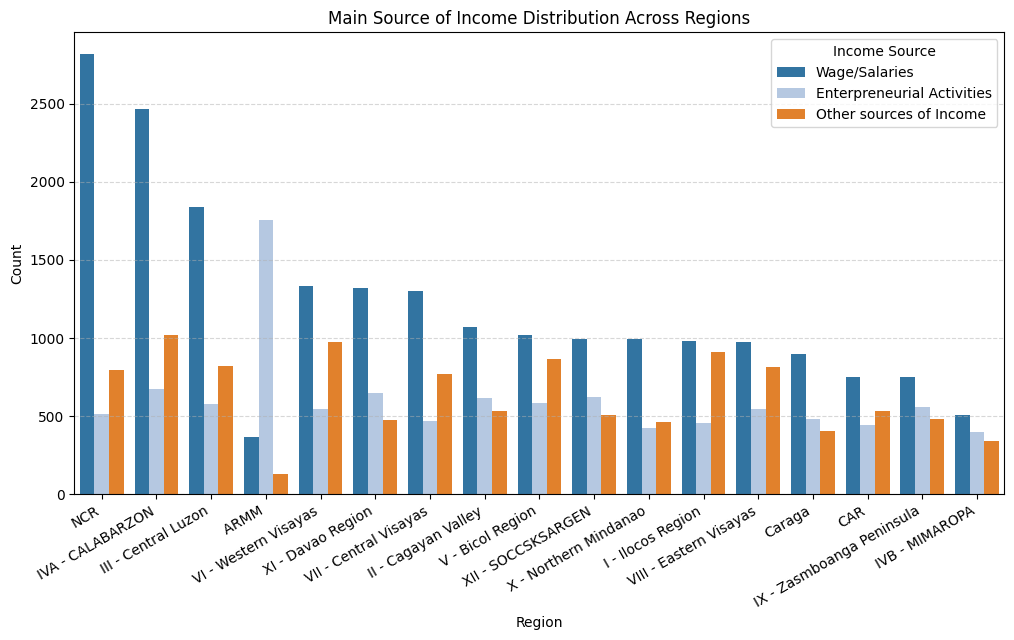

In [4]:
# Reset index for better formatting
per_region = per_region.reset_index()

plt.figure(figsize=(12,6))
sns.barplot(x="Region", y="Count", hue="Main Source of Income", data=per_region, palette="tab20")
plt.title("Main Source of Income Distribution Across Regions")
plt.xlabel("Region")
plt.ylabel("Count")
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.legend(title="Income Source")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

<b>Insight 1:</b> 

The data shows that <b>Wage/Salaries</b> are the primary income source for most Filipino households, with <b>NCR, CALABARZON, and Central Luzon</b> having the highest counts. <b>ARMM</b> stands out as an exception, where <b>Entrepreneurial Activities</b> are the dominant source of income, likely due to fewer formal job opportunities.

### Q2: How much does each region spend on other expenses?

In [5]:
lst = list(income.columns)
print(lst)

other_exp = [
    'Clothing, Footwear and Other Wear Expenditure', 'Housing and water Expenditure', 
    'Imputed House Rental Value', 'Medical Care Expenditure', 'Transportation Expenditure', 
    'Communication Expenditure', 'Education Expenditure', 'Miscellaneous Goods and Services Expenditure', 
    'Restaurant and hotels Expenditure', 'Special Occasions Expenditure', 'Crop Farming and Gardening expenses'
]

# Group by region and compute mean expense values
expense_scatter = income.groupby("Region")[other_exp].mean().round(2)

# Create a total expense column for sorting
expense_scatter["Total Expense"] = expense_scatter[other_exp].sum(axis=1)
expense_scatter = expense_scatter.sort_values(by="Total Expense", ascending=False)

expense_scatter

['Total Household Income', 'Region', 'Total Food Expenditure', 'Main Source of Income', 'Agricultural Household indicator', 'Bread and Cereals Expenditure', 'Total Rice Expenditure', 'Meat Expenditure', 'Total Fish and  marine products Expenditure', 'Fruit Expenditure', 'Vegetables Expenditure', 'Restaurant and hotels Expenditure', 'Alcoholic Beverages Expenditure', 'Tobacco Expenditure', 'Clothing, Footwear and Other Wear Expenditure', 'Housing and water Expenditure', 'Imputed House Rental Value', 'Medical Care Expenditure', 'Transportation Expenditure', 'Communication Expenditure', 'Education Expenditure', 'Miscellaneous Goods and Services Expenditure', 'Special Occasions Expenditure', 'Crop Farming and Gardening expenses', 'Total Income from Entrepreneurial Acitivites', 'Household Head Sex', 'Household Head Age', 'Household Head Marital Status', 'Household Head Highest Grade Completed', 'Household Head Job or Business Indicator', 'Household Head Occupation', 'Household Head Class of

,"Clothing, Footwear and Other Wear Expenditure",Housing and water Expenditure,Imputed House Rental Value,Medical Care Expenditure,Transportation Expenditure,Communication Expenditure,Education Expenditure,Miscellaneous Goods and Services Expenditure,Restaurant and hotels Expenditure,Special Occasions Expenditure,Crop Farming and Gardening expenses,Total Expense
Region,,,,,,,,,,,,
NCR,6976.98,93160.11,51101.16,9862.72,22546.10,10009.46,12021.56,21965.46,40036.05,5200.50,451.20,273331.30
IVA - CALABARZON,6081.77,49271.97,27064.07,10735.02,18396.81,6445.31,10028.40,17305.80,27326.60,6715.69,3022.15,182393.59
CAR,5720.25,43715.85,26579.89,9164.49,10700.99,3885.42,10560.51,12101.42,9588.11,5944.18,28428.27,166389.38
III - Central Luzon,5635.67,44391.07,23568.74,10135.67,15602.43,5428.20,8486.33,14893.83,19904.11,5991.85,11281.83,165319.73
II - Cagayan Valley,3758.88,27491.41,14501.96,5908.83,8924.35,2832.51,5867.15,10398.46,12534.84,4293.62,39485.11,135997.12
VII - Central Visayas,4376.98,38306.43,21495.43,7240.17,10843.88,3731.23,7007.65,10408.07,15706.88,5979.88,5332.65,130429.25
XI - Davao Region,4769.49,31926.51,17753.79,6485.55,11460.12,3193.57,7329.74,11255.10,12815.25,5917.80,15895.81,128802.73
I - Ilocos Region,5185.35,32065.86,17481.90,7722.50,10244.48,3906.28,5780.37,11736.45,16000.73,5233.20,13266.89,128624.01
IVB - MIMAROPA,4989.00,26010.86,13986.63,5141.53,8476.44,2523.54,6736.54,10534.42,7952.20,3954.20,23055.16,113360.52


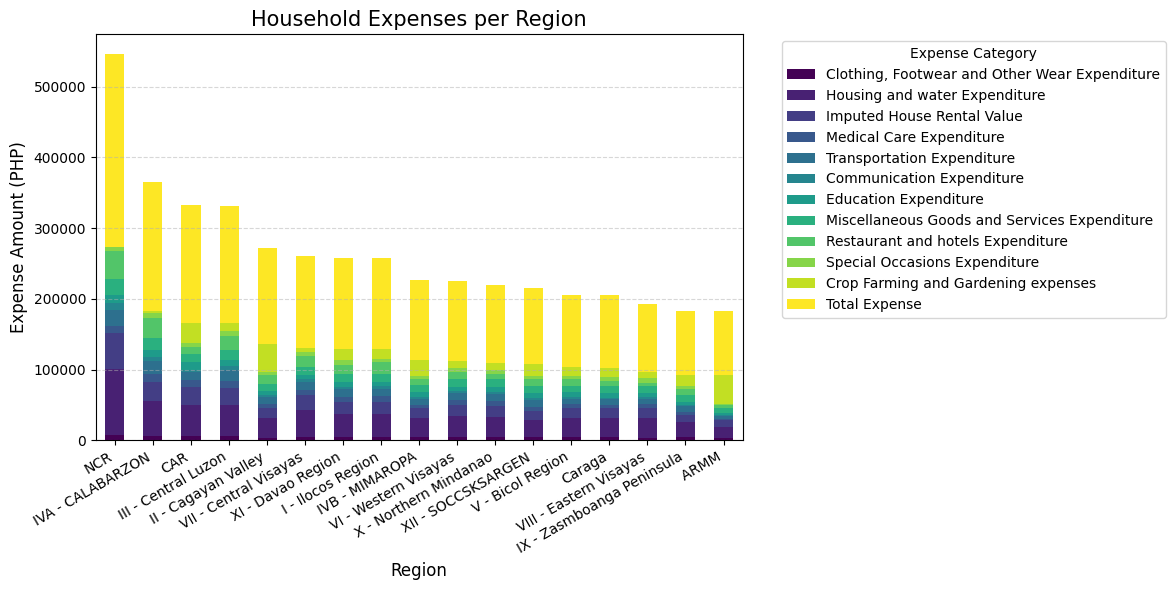

In [6]:
expense_scatter.plot(kind="bar", stacked=True, figsize=(12, 6), colormap="viridis")

plt.title("Household Expenses per Region", fontsize=15)
plt.xlabel("Region", fontsize=12)
plt.ylabel("Expense Amount (PHP)", fontsize=12)
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title="Expense Category", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Insight 2: 

### The following conclusions can be drawn:

- <b>NCR</b> leads in expenditures across multiple categories, including housing and water, rental costs, transportation, clothing and footwear, communication, education, restaurant and hotel expenses, as well as miscellaneous goods and services.

- Among all regions, <b>NCR spends the least on crop farming and gardening</b>.

- <b>ARMM</b> records the highest spending on crop farming and gardening but has the lowest expenditures in most other categories.

- <b>Cagayan Valley and Cordillera Administrative Region (CAR)</b> rank second and third, respectively, in crop farming and gardening expenses.

- <b>CALABARZON</b> stands out with the highest spending on both special occasions and medical care.

- <b>NCR</b> has the greatest overall expenditure on other expenses.

### Q3: Regions sorted by Total Income from Entrepreneurial Activities


In [7]:
entrep = income.groupby("Region")[["Total Income from Entrepreneurial Acitivites"]].mean().sort_values("Total Income from Entrepreneurial Acitivites").round(2)
entrep

,Total Income from Entrepreneurial Acitivites
Region,
V - Bicol Region,40572.59
X - Northern Mindanao,44369.91
VII - Central Visayas,45243.74
VI - Western Visayas,45555.90
Caraga,46335.23
XII - SOCCSKSARGEN,47365.94
VIII - Eastern Visayas,47450.77
I - Ilocos Region,47923.23
IVA - CALABARZON,49382.95


<Figure size 1800x1200 with 0 Axes>

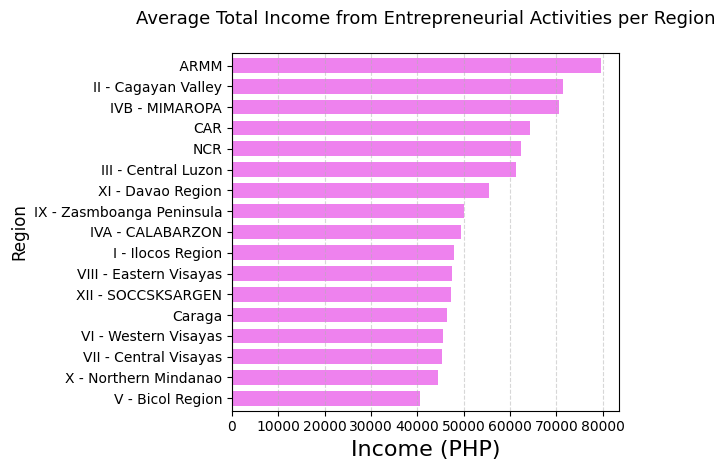

In [8]:
entrep = entrep.sort_values(by="Total Income from Entrepreneurial Acitivites", ascending=True)  

plt.figure(figsize=(18, 12))  
entrep.plot(kind="barh", color="violet", width=0.7, legend=False)  

plt.title("Average Total Income from Entrepreneurial Activities per Region\n", fontsize=13)
plt.xlabel("Income (PHP)", fontsize=16)
plt.ylabel("Region", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Insight 3: 
The data indicates that <b>ARMM</b> has the highest total income from entrepreneurial activities, suggesting a strong reliance on local businesses and agriculture. In contrast, <b>Bicol Region</b> has the lowest entrepreneurial income, likely reflecting a greater dependence on formal employment or other income sources.

### Q4: How does income level influence household expenditures across different regions?

In [9]:
income_vs_expenses = income.groupby("Region")[[
    'Total Household Income', 'Total Food Expenditure',
    'Bread and Cereals Expenditure', 'Total Rice Expenditure', 'Meat Expenditure',
    'Total Fish and  marine products Expenditure', 'Fruit Expenditure', 'Vegetables Expenditure',
    'Restaurant and hotels Expenditure', 'Alcoholic Beverages Expenditure', 'Tobacco Expenditure',
    'Clothing, Footwear and Other Wear Expenditure', 'Housing and water Expenditure',
    'Imputed House Rental Value', 'Medical Care Expenditure', 'Transportation Expenditure',
    'Communication Expenditure', 'Education Expenditure', 'Miscellaneous Goods and Services Expenditure',
    'Special Occasions Expenditure', 'Crop Farming and Gardening expenses',
    'Total Income from Entrepreneurial Acitivites'
]].mean().reset_index()

income_vs_expenses = income_vs_expenses.sort_values(by="Total Household Income", ascending=False)
income_vs_expenses

,Region,Total Household Income,Total Food Expenditure,Bread and Cereals Expenditure,Total Rice Expenditure,Meat Expenditure,Total Fish and marine products Expenditure,Fruit Expenditure,Vegetables Expenditure,Restaurant and hotels Expenditure,...,Housing and water Expenditure,Imputed House Rental Value,Medical Care Expenditure,Transportation Expenditure,Communication Expenditure,Education Expenditure,Miscellaneous Goods and Services Expenditure,Special Occasions Expenditure,Crop Farming and Gardening expenses,Total Income from Entrepreneurial Acitivites
9,NCR,420861.861501,127080.456659,24728.881840,16195.817918,17362.191768,11129.341646,3577.542131,5633.564891,40036.045036,...,93160.109927,51101.155932,9862.722276,22546.104116,10009.457143,12021.555206,21965.459564,5200.498547,451.197094,62477.074576
6,IVA - CALABARZON,303360.536040,105333.949543,24571.531716,17260.889957,15090.317876,10737.155935,2938.367612,4968.399568,27326.596828,...,49271.966843,27064.071120,10735.019942,18396.807304,6445.308986,10028.401249,17305.797693,6715.687890,3022.153051,49382.946180
5,III - Central Luzon,292965.181650,99726.701576,25187.200185,17846.424158,15639.873031,11289.561631,2680.144887,5732.405931,19904.109978,...,44391.071362,23568.735867,10135.666976,15602.433735,5428.202039,8486.333642,14893.833179,5991.851715,11281.834415,61263.363917
1,CAR,269540.484638,80352.780290,26666.110145,20975.441159,12220.992464,8357.065507,2922.601159,6406.842319,9588.107826,...,43715.846957,26579.888696,9164.489855,10700.991304,3885.419130,10560.509565,12101.415652,5944.177971,28428.265507,64282.409855
15,XI - Davao Region,238115.891251,81126.927228,24991.007768,17408.363451,9498.749796,12133.204415,2252.839330,4860.865495,12815.245298,...,31926.512674,17753.793949,6485.546198,11460.115290,3193.574816,7329.742028,11255.102208,5917.804170,15895.808258,55533.534751
3,I - Ilocos Region,238110.084327,80649.937819,22724.907155,17439.663543,11827.419080,8791.235945,2133.184838,5070.663969,16000.732112,...,32065.857751,17481.899489,7722.497871,10244.478705,3906.283646,5780.371806,11736.449744,5233.195911,13266.888842,47923.229983
4,II - Cagayan Valley,236778.221721,75604.358269,21411.527715,16563.448851,12307.674178,8666.757999,1887.808923,5550.478594,12534.839117,...,27491.405137,14501.964849,5908.832357,8924.347003,2832.511041,5867.151870,10398.459667,4293.616945,39485.111762,71534.284362
12,VII - Central Visayas,234909.314050,84307.184179,25976.362456,15318.150335,8878.966549,11247.982684,2432.853207,4251.927981,15706.882330,...,38306.429752,21495.426210,7240.165289,10843.884298,3731.230224,7007.647776,10408.073200,5979.883510,5332.653680,45243.742227
11,VI - Western Visayas,220481.260260,79829.025956,26411.292178,20756.341284,8709.301999,12014.820414,2733.205542,5274.115047,9761.875132,...,29842.945633,15770.256051,6987.667134,9570.517713,3055.269028,5973.481585,10732.587864,5708.840056,10462.552788,45555.904595
7,IVB - MIMAROPA,216685.124900,70760.293835,25283.614091,20460.674139,7919.929544,9181.916733,2491.857486,4575.049640,7952.201761,...,26010.859888,13986.629303,5141.533227,8476.438751,2523.540432,6736.542034,10534.419536,3954.203363,23055.162530,70514.190552


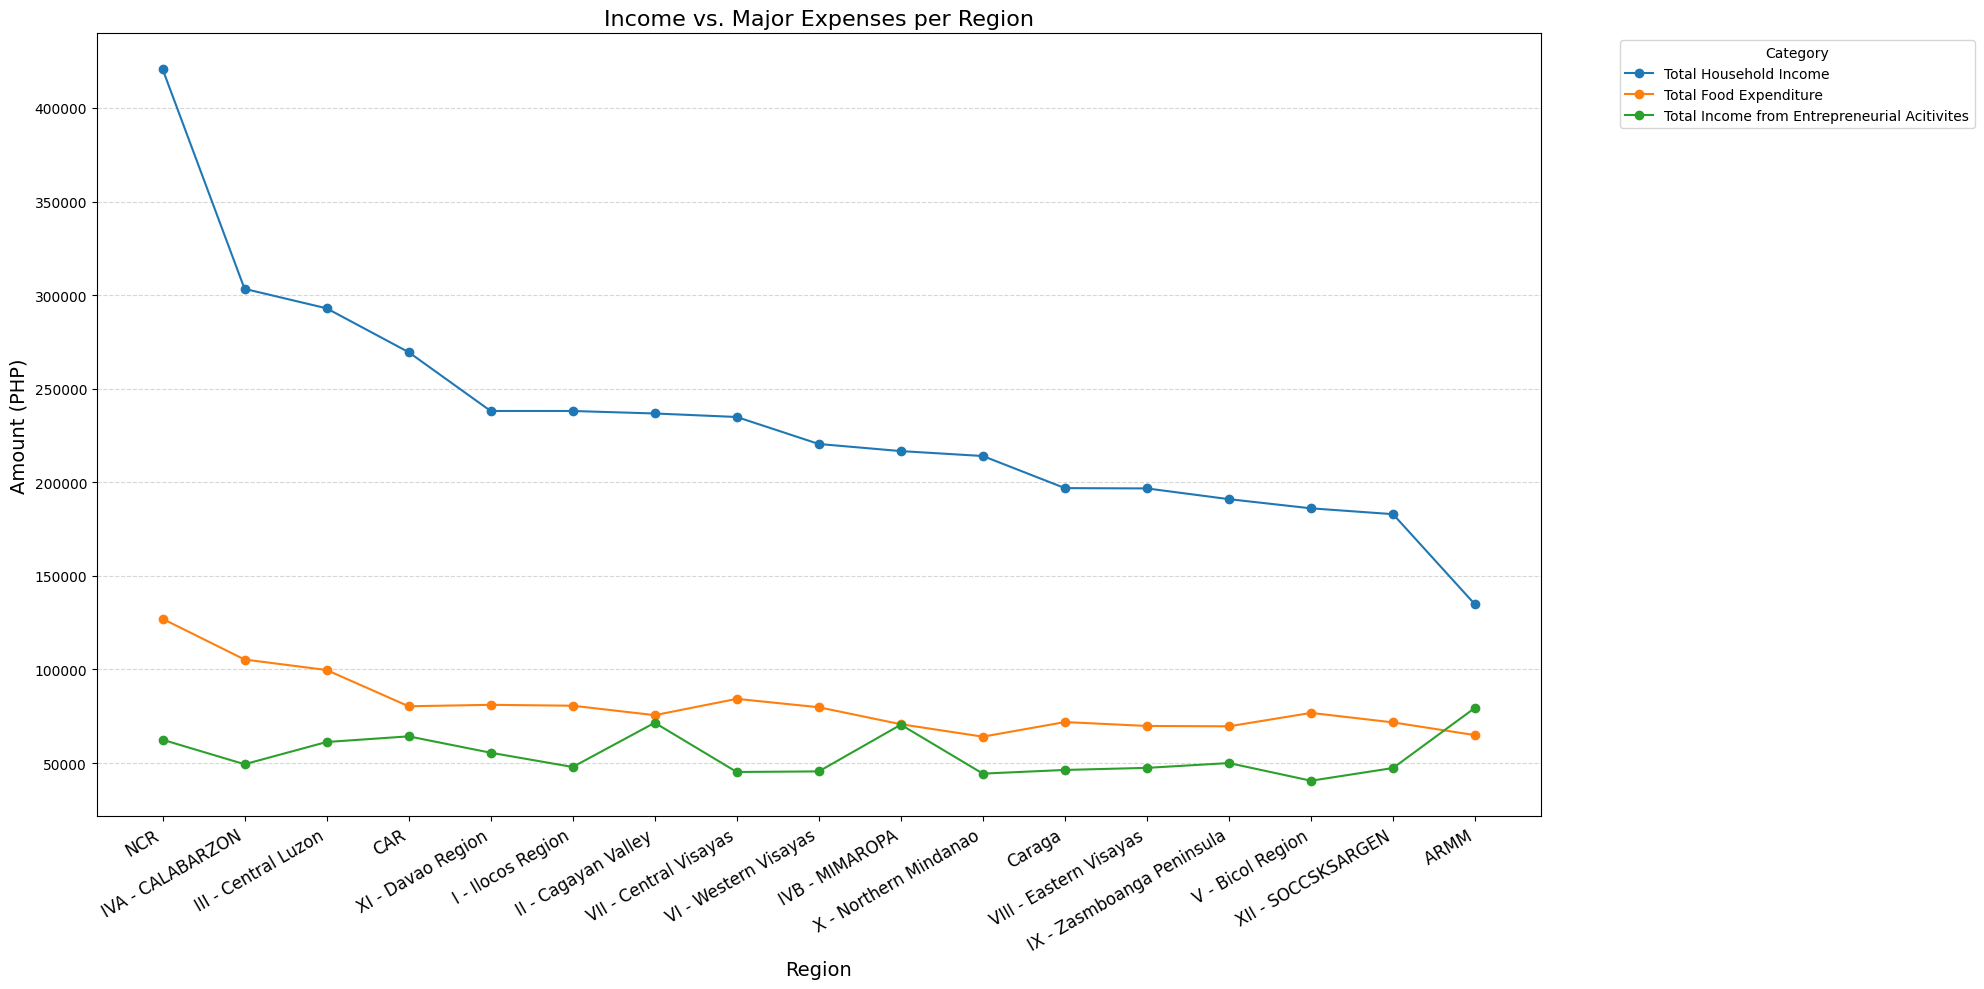

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))  

for col in ['Total Household Income', 'Total Food Expenditure', 'Total Income from Entrepreneurial Acitivites']:
    plt.plot(income_vs_expenses["Region"], income_vs_expenses[col], marker='o', label=col)

plt.title("Income vs. Major Expenses per Region", fontsize=16)
plt.xlabel("Region", fontsize=14)
plt.ylabel("Amount (PHP)", fontsize=14)
plt.xticks(rotation=30, ha='right', fontsize=12)  
plt.legend(title="Category", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


### Insight 4:

### The following conclusions can be made:

- <b>Total Household Income</b> affects Total Food Expenditure. Higher-income households tend to spend more on food.

- Total Household Income affects the <b>Ratio of Food Expenditure to Income</b>. Lower-income households allocate a larger share of their earnings to food, while higher-income households spend a smaller percentage.

- Total Household Income influences Other Expenses. Higher-income households spend more on non-food items like housing, education, and transportation.

### Q5: What are the proportions of the sources of income per region?

In [44]:
per_region = income.groupby(["Region", "Main Source of Income"]).size().to_frame()

new_region = per_region.unstack(level=1).reset_index()
new_region.columns = new_region.columns.droplevel(0)
new_region.columns = ["Region", "Enterpreneurial Activities", "Other sources of Income", "Wage/Salaries"]

new_region

,Region,Enterpreneurial Activities,Other sources of Income,Wage/Salaries
0,ARMM,1753,127,368
1,CAR,442,531,752
2,Caraga,481,406,895
3,I - Ilocos Region,457,912,979
4,II - Cagayan Valley,619,532,1068
5,III - Central Luzon,578,819,1840
6,IVA - CALABARZON,675,1021,2466
7,IVB - MIMAROPA,401,338,510
8,IX - Zasmboanga Peninsula,559,481,748
9,NCR,517,797,2816


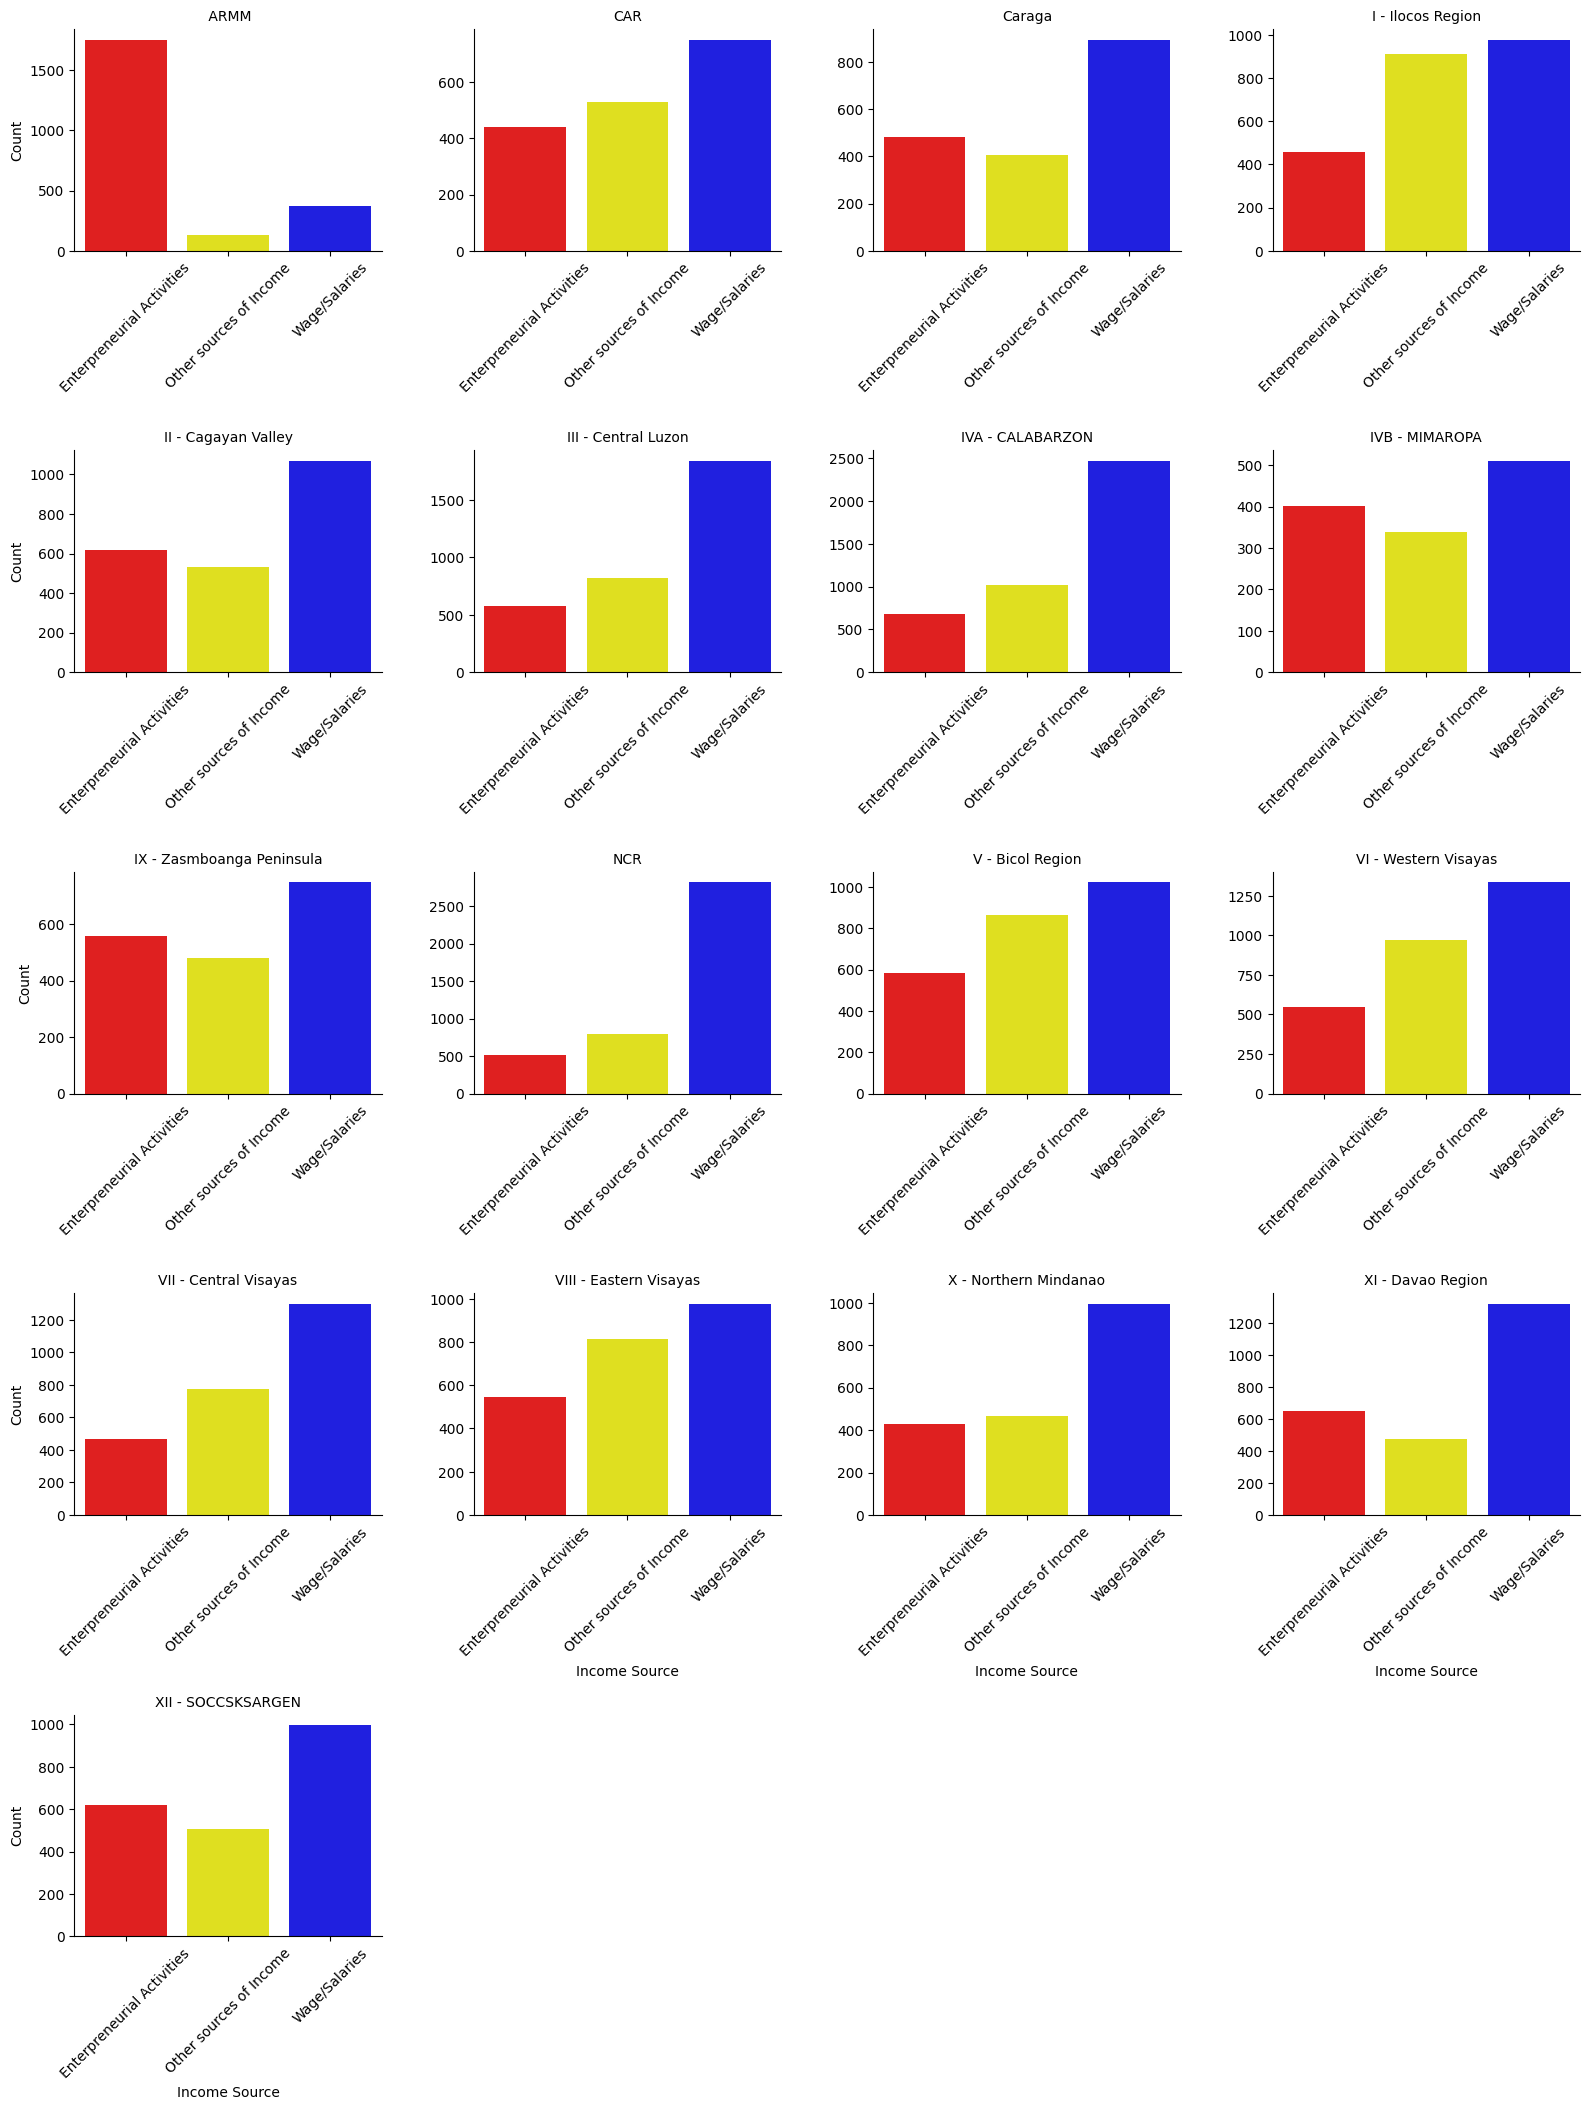

In [52]:
new_region_melted = new_region.melt(id_vars=["Region"], var_name="Income Source", value_name="Count")

# Custom colors for the three categories 
color_palette = {"Enterpreneurial Activities": "red", "Other sources of Income": "yellow", "Wage/Salaries": "blue"}

# Facet grid with one chart per region
g = sns.FacetGrid(new_region_melted, col="Region", col_wrap=4, sharex=False, sharey=False, height=4)
g.map_dataframe(sns.barplot, x="Income Source", y="Count", order=["Enterpreneurial Activities", "Other sources of Income", "Wage/Salaries"], palette=color_palette)

g.set_titles("{col_name}")
g.set_xticklabels(rotation=45)

g.fig.subplots_adjust(hspace=0.9, wspace=0.3) 
plt.show()

### Insight 5:

### The following Conclusions can be made:

- <b>ARMM</b> is the only region with Entrepreneurial Activities being the Main Source of Income (0.78 or 78%).
- <b>NCR</b> has the highest ratio of Wage/Salaries as main source of income (0.68 or 68%).
- <b>NCR</b> has the lowest ratio on Entrepreneurial Activities (0.125 or 12.5%).
- All regions except <b>ARMM</b> has Wage/Salaries as their Main Source of Income

### Q6: What is the Average Yearly Food Expenditure and Average Income per region? Which region has the highest and lowest??

In [11]:
# Calculate average food expenditure and income per region
total_food = income.groupby("Region")[["Total Food Expenditure", "Total Household Income"]].mean().round(2)

# Sort to identify highest and lowest
sorted_food = total_food.sort_values(by=["Total Food Expenditure", "Total Household Income"])

print("\033[1mAverage Yearly Food Expenditure and Income per Region\033[0m\n")
print(total_food)

print("\n\033[1mRegion with Lowest Average Food Expenditure and Income\033[0m")
print(sorted_food.head(1))

print("\n\033[1mRegion with Highest Average Food Expenditure and Income\033[0m")
print(sorted_food.tail(1))

Average Yearly Food Expenditure and Income per Region

                           Total Food Expenditure  Total Household Income
Region                                                                   
 ARMM                                    64931.27               134746.82
CAR                                      80352.78               269540.48
Caraga                                   71912.66               196907.38
I - Ilocos Region                        80649.94               238110.08
II - Cagayan Valley                      75604.36               236778.22
III - Central Luzon                      99726.70               292965.18
IVA - CALABARZON                        105333.95               303360.54
IVB - MIMAROPA                           70760.29               216685.12
IX - Zasmboanga Peninsula                69645.32               191000.91
NCR                                     127080.46               420861.86
V - Bicol Region                         76811.41        

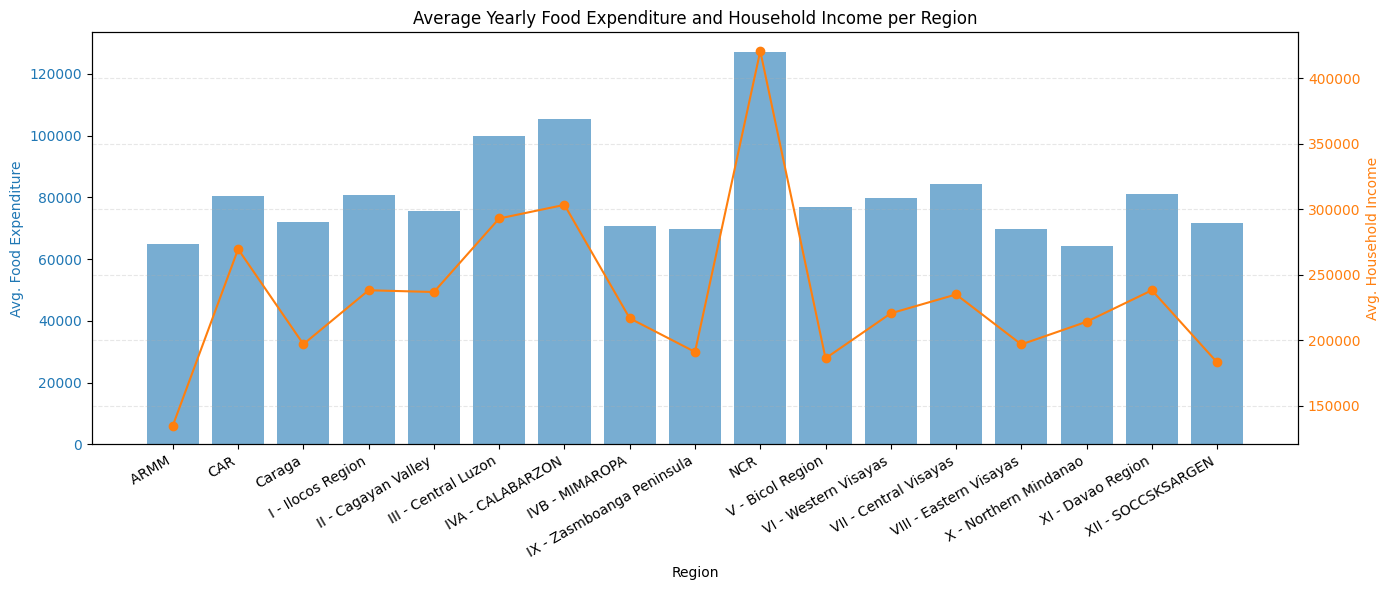

In [12]:
# Calculate average food expenditure and income per region
total_food = income.groupby("Region")[["Total Food Expenditure", "Total Household Income"]].mean().round(2).reset_index()

# Sort for reference (it is not required for plotting)
sorted_food = total_food.sort_values(by=["Total Food Expenditure", "Total Household Income"])

fig, ax1 = plt.subplots(figsize=(14,6))

# Plot Food Expenditure
color = 'tab:blue'
ax1.set_xlabel("Region")
ax1.set_ylabel("Avg. Food Expenditure", color=color)
ax1.bar(total_food["Region"], total_food["Total Food Expenditure"], color=color, alpha=0.6, label="Food Expenditure")
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticklabels(total_food["Region"], rotation=30, ha='right', fontsize=10)

# Plot Income on secondary axis
ax2 = ax1.twinx()
color = 'tab:orange'
ax2.set_ylabel("Avg. Household Income", color=color)
ax2.plot(total_food["Region"], total_food["Total Household Income"], color=color, marker='o', label="Household Income")
ax2.tick_params(axis='y', labelcolor=color)

plt.title("Average Yearly Food Expenditure and Household Income per Region")
plt.grid(axis='y', linestyle='--', alpha=0.3)
fig.tight_layout()
plt.show()


### Insight 6:

### The data shows the following:

- <b>NCR</b> has the highest income and food expenditure, meaning households there earn more and spend more on food.

- <b>Northern Mindanao</b> has the lowest food expenditure, suggesting lower spending capacity or more cost-effective food consumption.

- <b>Regions with lower household income</b> tend to have lower food expenditure, showing a direct relationship between income levels and spending habits.

### Q7: What is the ratio of Food Expenditure to income per region? Which region has the highest and lowest?

In [13]:
# Add the food-to-income ratio column
income["Ratio of Food Expenditure to Income"] = income["Total Food Expenditure"] / income["Total Household Income"]

# Compute average ratio per region
res = income.groupby("Region")[["Ratio of Food Expenditure to Income"]].mean().round(2)

# Sort to identify highest and lowest
sorted_ratio = res.sort_values(by="Ratio of Food Expenditure to Income")

print("\033[1mRatio of Food Expenditure to Income per Region\033[0m\n")
print(res)

print("\n\033[1mRegion with Lowest Food-to-Income Ratio\033[0m")
print(sorted_ratio.head(1))

print("\n\033[1mRegion with Highest Food-to-Income Ratio\033[0m")
print(sorted_ratio.tail(1))

Ratio of Food Expenditure to Income per Region

                           Ratio of Food Expenditure to Income
Region                                                        
 ARMM                                                     0.54
CAR                                                       0.40
Caraga                                                    0.47
I - Ilocos Region                                         0.42
II - Cagayan Valley                                       0.40
III - Central Luzon                                       0.43
IVA - CALABARZON                                          0.42
IVB - MIMAROPA                                            0.44
IX - Zasmboanga Peninsula                                 0.44
NCR                                                       0.37
V - Bicol Region                                          0.51
VI - Western Visayas                                      0.47
VII - Central Visayas                                     0.51
VIII - 

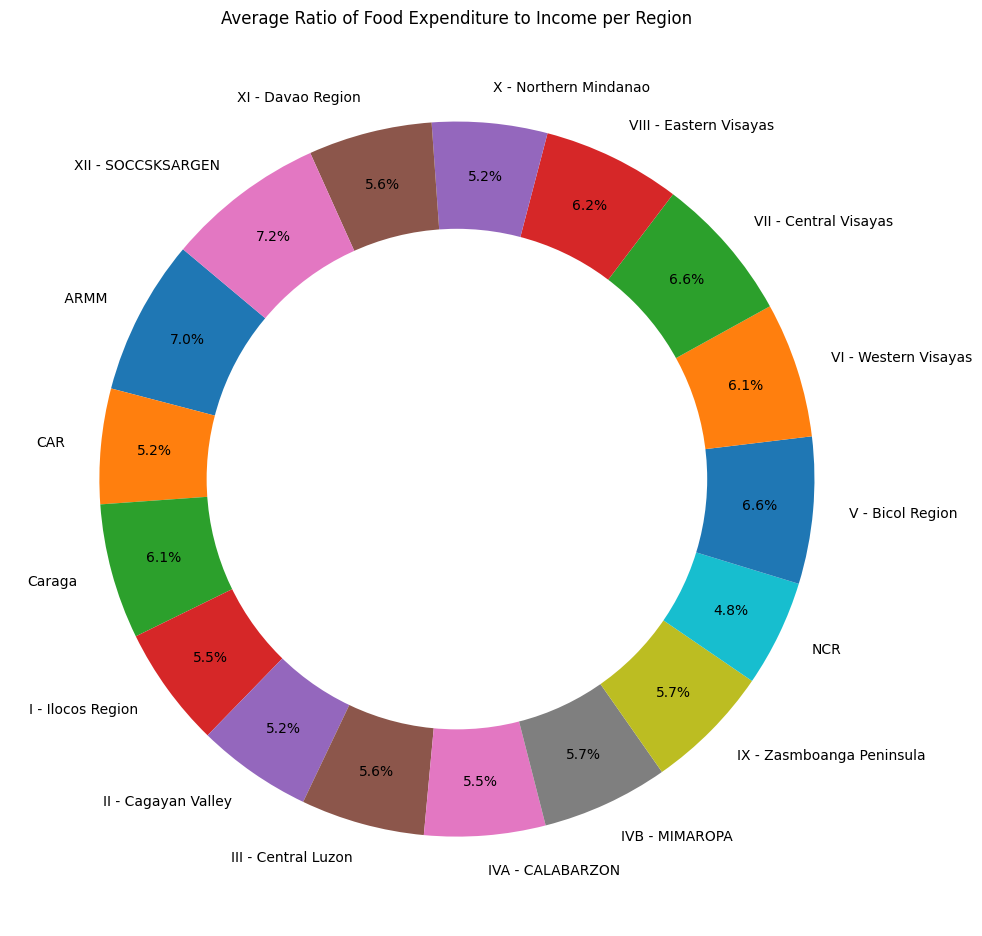

In [14]:
res = income.groupby("Region")[["Ratio of Food Expenditure to Income"]].mean().round(2)

# Reset index for plotting the data
res = res.reset_index()

# Prepare data
labels = res["Region"]
sizes = res["Ratio of Food Expenditure to Income"]

plt.figure(figsize=(10, 10))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, pctdistance=0.85)

# Circle for donut style effect
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# Chart aesthetics
plt.title("Average Ratio of Food Expenditure to Income per Region")
plt.tight_layout()
plt.show()

### Insight 7:

### The data shows the following:

- <b>SOCCSKSARGEN</b> has the highest food-to-income ratio (0.55 or 55%), meaning a larger portion of household income is spent on food. This suggests either lower total income levels or higher food costs relative to earnings.

- <b>NCR</b> has the lowest food-to-income ratio (0.37 or 37%), indicating that while food expenditure is high, total income is significantly higher—allowing households to allocate a smaller percentage toward food expenses.

- Regions with lower total household income, such as <b>ARMM (0.54) and Bicol (0.51)</b>, also show high food-to-income ratios, suggesting that food remains a significant cost burden in lower-income areas.

- Higher-income regions like <b>CAR, Cagayan Valley, and Northern Mindanao</b> have lower ratios (around 0.40), indicating that a smaller fraction of earnings goes toward food spending.

### Q8: What is the average number of family members per region?

In [15]:
avg_family_members = income.groupby('Region')['Total Number of Family members'].mean().reset_index()
avg_family_members.columns = ['Region', 'Average_Family_Members']
avg_family_members

,Region,Average_Family_Members
0,ARMM,5.708185
1,CAR,4.668986
2,Caraga,4.641414
3,I - Ilocos Region,4.560903
4,II - Cagayan Valley,4.382154
5,III - Central Luzon,4.619092
6,IVA - CALABARZON,4.451706
7,IVB - MIMAROPA,4.394716
8,IX - Zasmboanga Peninsula,4.552013
9,NCR,4.533414


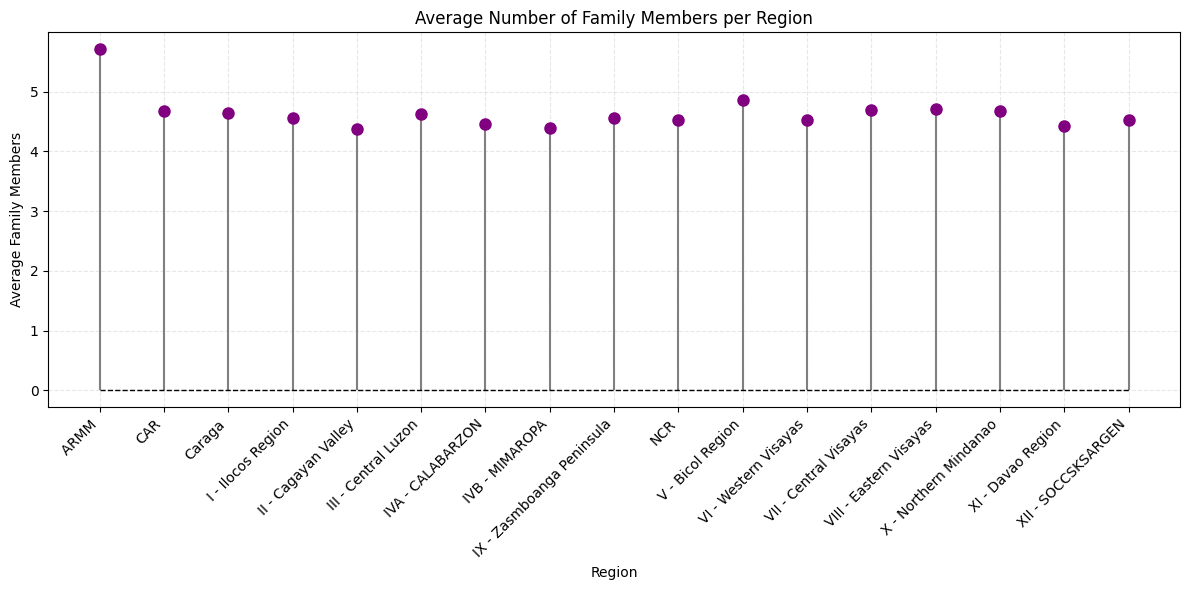

In [16]:
plt.figure(figsize=(12, 6))
markerline, stemlines, baseline = plt.stem(avg_family_members['Region'], avg_family_members['Average_Family_Members'])

# Customize style stems of the graph
plt.setp(markerline, marker='o', markersize=8, color='purple')
plt.setp(stemlines, linestyle='-', color='gray')
plt.setp(baseline, linestyle='--', color='black', linewidth=1)

plt.title("Average Number of Family Members per Region")
plt.xlabel("Region")
plt.ylabel("Average Family Members")
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### Insight 8: 

The data shows that <b>ARMM has the highest average number of family members (5.71)</b>, indicating larger household sizes compared to other regions. This could be due to cultural factors, socioeconomic conditions, or family support structures.

On the other hand, <b>Cagayan Valley (4.38) and MIMAROPA (4.39) have the smallest average household sizes</b>, suggesting relatively fewer family members per household in these areas.

Most regions have an <b>average between 4.4 and 4.7 family members</b>, showing a relatively stable household size across the country, with only ARMM standing out as an outlier.

### Q9: What is the total number of employed family members per region?

In [17]:
total_employed_per_region = income.groupby('Region')['Total number of family members employed'].sum().reset_index()
total_employed_per_region.columns = ['Region', 'Total_Employed_Members']
total_employed_per_region.sort_values(by='Total_Employed_Members', ascending=False)

total_employed_per_region

,Region,Total_Employed_Members
0,ARMM,802
1,CAR,2472
2,Caraga,2133
3,I - Ilocos Region,3100
4,II - Cagayan Valley,3340
5,III - Central Luzon,4715
6,IVA - CALABARZON,6172
7,IVB - MIMAROPA,1401
8,IX - Zasmboanga Peninsula,1986
9,NCR,6258


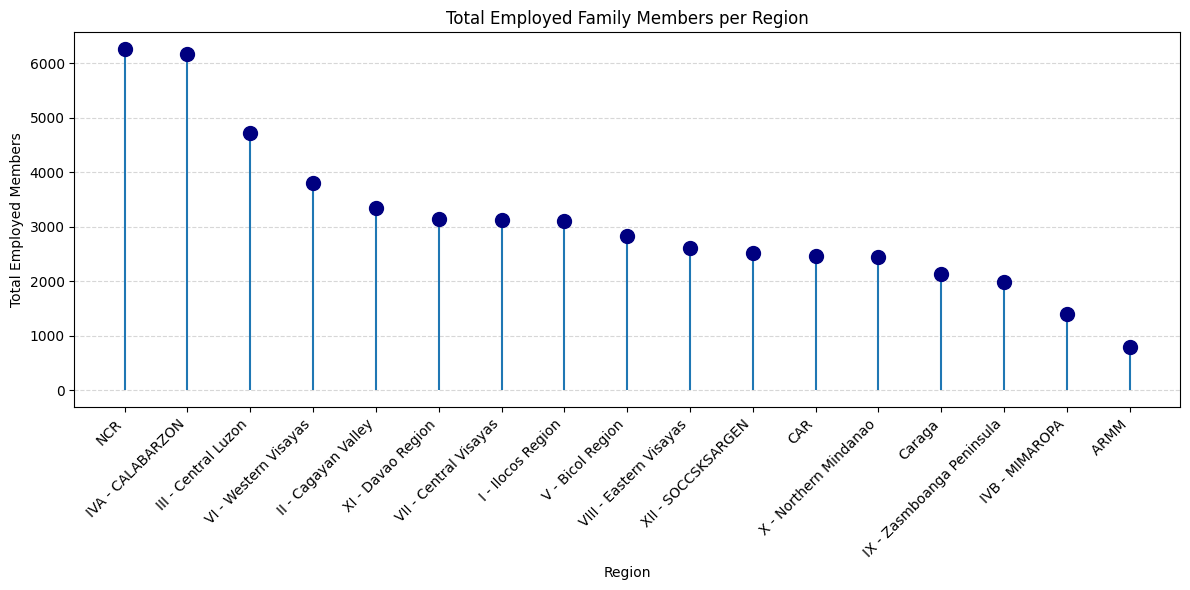

In [18]:
data = total_employed_per_region.sort_values(by='Total_Employed_Members', ascending=False)

plt.figure(figsize=(12, 6))
markerline, stemlines, baseline = plt.stem(data['Region'], data['Total_Employed_Members'], basefmt=" ")
plt.setp(markerline, marker='o', markersize=10, color='navy')
plt.title("Total Employed Family Members per Region")
plt.xlabel("Region")
plt.ylabel("Total Employed Members")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Insight 9:

The data shows that <b>NCR has the highest number of employed family members (6,258)</b>, likely due to its dense urban population and economic opportunities. <b>CALABARZON (6,172)</b> also has a high employment count, reflecting its strong industrial and economic zones.

On the other hand, <b>ARMM has the lowest total employed family members (802)</b>, which may be influenced by economic conditions or fewer job opportunities in the region.

### Q10: How does the average household savings rate (income minus total expenditure) vary across regions, and which region has the highest average savings?

In [19]:
# Define total expenditure correctly by summing relevant expense columns
income["Total Expenditure"] = (
    income[
        [
            "Total Food Expenditure", "Housing and water Expenditure",
            "Medical Care Expenditure", "Transportation Expenditure",
            "Communication Expenditure", "Education Expenditure",
            "Miscellaneous Goods and Services Expenditure",
            "Special Occasions Expenditure"
        ]
    ].sum(axis=1)
)

# Calculate household savings (Income - Total Expenditure)
income["Household Savings"] = income["Total Household Income"] - income["Total Expenditure"]

# Compute average savings per region
avg_savings_per_region = income.groupby("Region")["Household Savings"].mean().reset_index()
avg_savings_per_region.columns = ["Region", "Average_Household_Savings"]

# Sort to identify highest and lowest savings regions
sorted_savings = avg_savings_per_region.sort_values(by="Average_Household_Savings", ascending=False)

print("\033[1mAverage Household Savings per Region\033[0m\n")
print(avg_savings_per_region)

print("\n\033[1mRegion with Highest Average Household Savings\033[0m")
print(sorted_savings.head(1))

print("\n\033[1mRegion with Lowest Average Household Savings\033[0m")
print(sorted_savings.tail(1))


Average Household Savings per Region

                       Region  Average_Household_Savings
0                        ARMM               34732.623221
1                         CAR               93114.853913
2                      Caraga               61199.180696
3           I - Ilocos Region               80771.011073
4         II - Cagayan Valley               95457.539432
5         III - Central Luzon               88309.087427
6            IVA - CALABARZON               79127.596588
7              IVB - MIMAROPA               82547.293835
8   IX - Zasmboanga Peninsula               68535.908277
9                         NCR              119015.498063
10           V - Bicol Region               46039.919094
11       VI - Western Visayas               68780.925289
12      VII - Central Visayas               67084.815821
13     VIII - Eastern Visayas               62208.568678
14      X - Northern Mindanao               78405.994171
15          XI - Davao Region               79420.

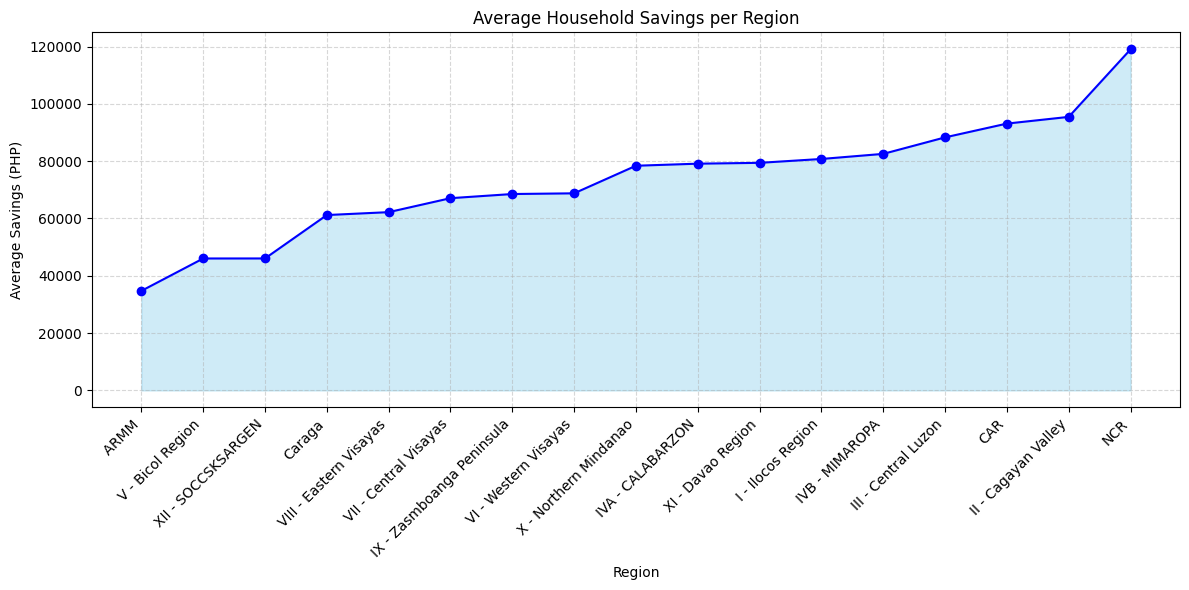

In [20]:
data = avg_savings_per_region.sort_values(by='Average_Household_Savings')

plt.figure(figsize=(12, 6))
plt.fill_between(data['Region'], data['Average_Household_Savings'], color='skyblue', alpha=0.4)
plt.plot(data['Region'], data['Average_Household_Savings'], color='blue', marker='o')
plt.title("Average Household Savings per Region")
plt.xlabel("Region")
plt.ylabel("Average Savings (PHP)")
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Insight 10:

The data shows that <b>NCR</b> has the highest average household savings (₱119,015.50), likely due to higher income levels and better economic opportunities, allowing households to retain more of their earnings.

On the other hand, <b>ARMM</b> has the lowest average household savings (₱34,732.62), suggesting either lower household income or higher essential expenditures that reduce savings capacity.

### Q11: Which region in the Philippines has the highest average spending on non-food (other) household expenses?

In [21]:
other_exp = [
    'Clothing, Footwear and Other Wear Expenditure',
    'Housing and water Expenditure',
    'Imputed House Rental Value',
    'Medical Care Expenditure',
    'Transportation Expenditure',
    'Communication Expenditure',
    'Education Expenditure',
    'Miscellaneous Goods and Services Expenditure',
    'Restaurant and hotels Expenditure',
    'Special Occasions Expenditure',
    'Crop Farming and Gardening expenses'
]

# Calculate total other expenses per household
income["Total Other Expenses"] = income[other_exp].sum(axis=1)

# Calculate the average total other expenses per region
average_other_expense = income.groupby("Region")["Total Other Expenses"].mean().round(2)

# Find the region with the highest average other expenses
highest_expense_region = average_other_expense.idxmax()
highest_expense_value = average_other_expense.max()

print(f"The region with the highest average other expenses is {highest_expense_region} with an amount of {highest_expense_value}.")


The region with the highest average other expenses is NCR with an amount of 273331.28.


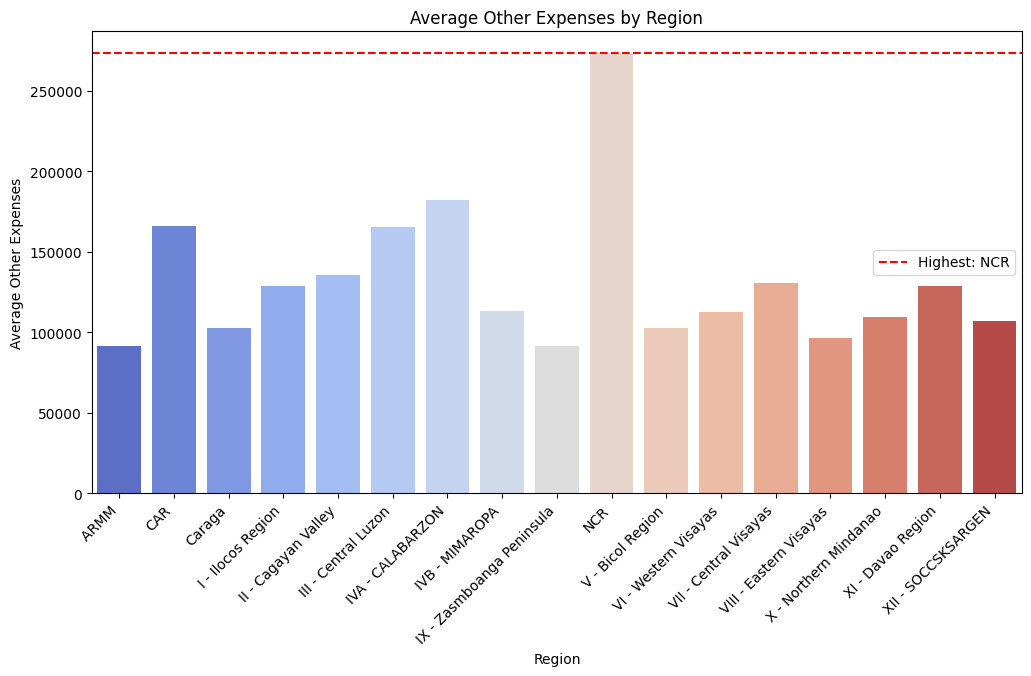

In [22]:
# Create a bar plot
plt.figure(figsize=(12, 6))
sns.barplot(x=average_other_expense.index, y=average_other_expense.values, palette="coolwarm")

plt.xticks(rotation=45, ha='right')
plt.xlabel("Region")
plt.ylabel("Average Other Expenses")
plt.title("Average Other Expenses by Region")

# Annotate highest expense region
highest_expense_region = average_other_expense.idxmax()
highest_expense_value = average_other_expense.max()
plt.axhline(highest_expense_value, color='red', linestyle='--', label=f'Highest: {highest_expense_region}')
plt.legend()

plt.show()

<b>Insight 11:</b> 

The analysis shows that <b>NCR</b> is the region in the Philippines that spend more on non-food expenses like housing, education, and transportation. The region with the highest average other expenses likely has a higher cost of living or better access to services.

<b>Key Insights:</b>

Higher-income households spend more on non-food needs. As household income increases, families are more likely to allocate more funds to non-food expenses such as housing, healthcare, education, and transportation.

Income levels strongly influence both food and non-food spending patterns. Higher-income households tend to spend a smaller percentage of their income on food, while allocating more toward non-food expenses. In contrast, lower-income households often spend a larger portion of their income on food and less on other services.

### Q12: Which region spends the most on medical care on average?

In [23]:
# Group by region and calculate average medical care expenditure
avg_medical = income.groupby("Region")["Medical Care Expenditure"].mean().round(2)

# Identify the region with the highest medical expenditure
top_medical_region = avg_medical.idxmax()
top_medical_value = avg_medical.max()

print(f"The region that spends the most on medical care on average is {top_medical_region} with an average of {top_medical_value}.")


The region that spends the most on medical care on average is IVA - CALABARZON with an average of 10735.02.


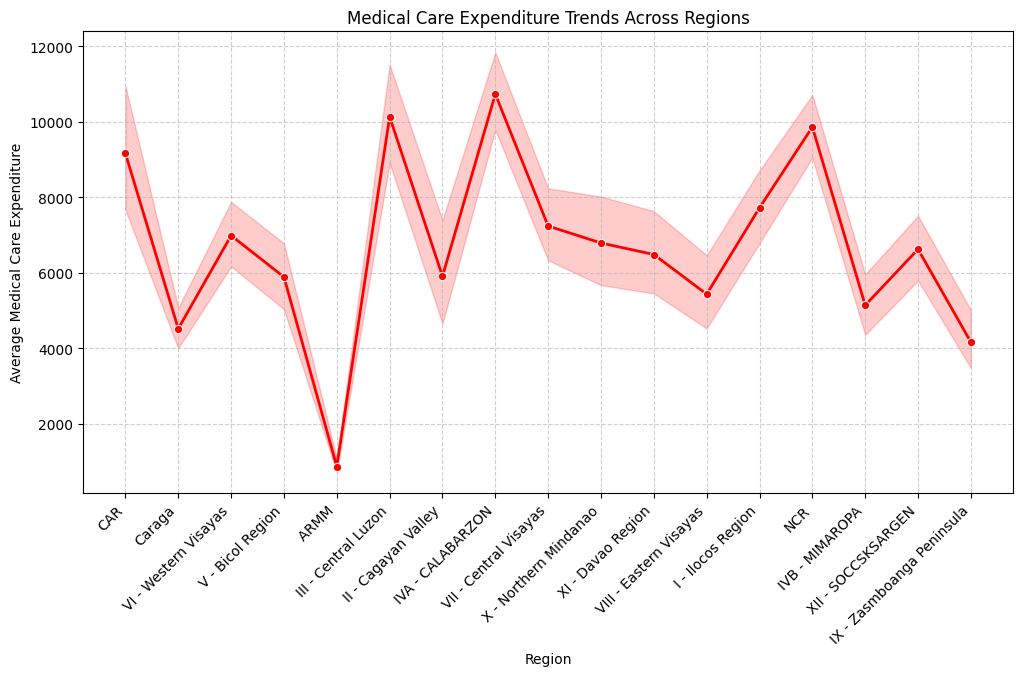

In [24]:
plt.figure(figsize=(12, 6))
sns.lineplot(x=income["Region"], y=income["Medical Care Expenditure"], marker="o", color="red", linewidth=2)

plt.xticks(rotation=45, ha="right")
plt.xlabel("Region")
plt.ylabel("Average Medical Care Expenditure")
plt.title("Medical Care Expenditure Trends Across Regions")

plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

### Insight 12:

The region that spends the most on medical care on average is <b>IVA – CALABARZON</b>, with an average expenditure of ₱10,735.02.

### This suggests that:

Access to healthcare services may be more readily available in <b>CALABARZON</b>, allowing households to spend more on medical needs.
Higher income levels in the region may enable families to afford better or more frequent healthcare.
The cost of healthcare in this region might be higher due to urbanization and private service options.

#### Q13: Where is rice the most heavily consumed or valued, based on household spending? 

In [25]:
avg_rice = income.groupby("Region")["Total Rice Expenditure"].mean().round(2)
top_rice_region = avg_rice.idxmax()
top_rice_value = avg_rice.max()

print(f"The region that spends the most on rice is {top_rice_region} with an average of ₱{top_rice_value}.")


The region that spends the most on rice is VIII - Eastern Visayas with an average of ₱21334.34.


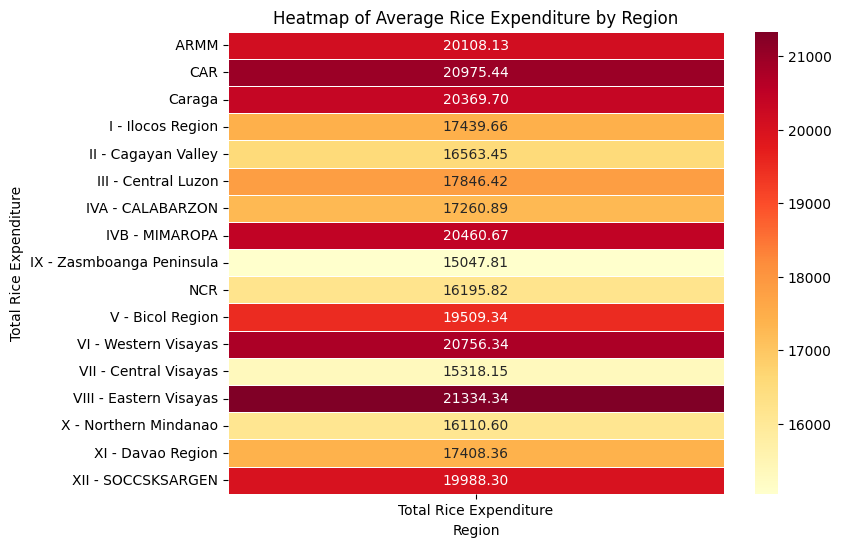

In [26]:
avg_rice_df = avg_rice.reset_index()
avg_rice_df = avg_rice_df.pivot_table(values="Total Rice Expenditure", index="Region")

plt.figure(figsize=(8, 6))
sns.heatmap(avg_rice_df, cmap="YlOrRd", annot=True, fmt=".2f", linewidths=0.5)

plt.title("Heatmap of Average Rice Expenditure by Region")
plt.xlabel("Region")
plt.ylabel("Total Rice Expenditure")
plt.show()

### Insight 13: 

The region that spends the most on rice is <b>VIII - Eastern Visayas with an average of ₱21334.34</b>.
Insight 13: The region that spends the most on rice is Region VIII – Eastern Visayas, with an average annual rice expenditure of ₱21,334.34 per household.

## This suggests that:

- Rice plays a central role in household consumption in Eastern Visayas, possibly more than in other regions.
- The high spending may reflect greater household rice consumption, larger family sizes, or higher local rice prices.
- It may also indicate limited access to alternative staple foods or reliance on purchased rice rather than home-grown supply.

### Q14: What factors are most closely associated with household spending on rice in the Philippines?

In [27]:
# Select variables to correlate with rice expenditure
correlation_vars = [
    "Total Rice Expenditure",
    "Total Household Income",
    "Total Food Expenditure",
    "Agricultural Household indicator",
    "Education Expenditure",
    "Medical Care Expenditure"
]

# Compute correlation matrix
rice_corr = income[correlation_vars].corr().round(2)

# Print correlation of rice expenditure with other variables
print("Correlation with Total Rice Expenditure:")
print(rice_corr["Total Rice Expenditure"].sort_values(ascending=False))


Correlation with Total Rice Expenditure:
Total Rice Expenditure              1.00
Total Food Expenditure              0.44
Total Household Income              0.16
Education Expenditure               0.10
Medical Care Expenditure            0.02
Agricultural Household indicator   -0.04
Name: Total Rice Expenditure, dtype: float64


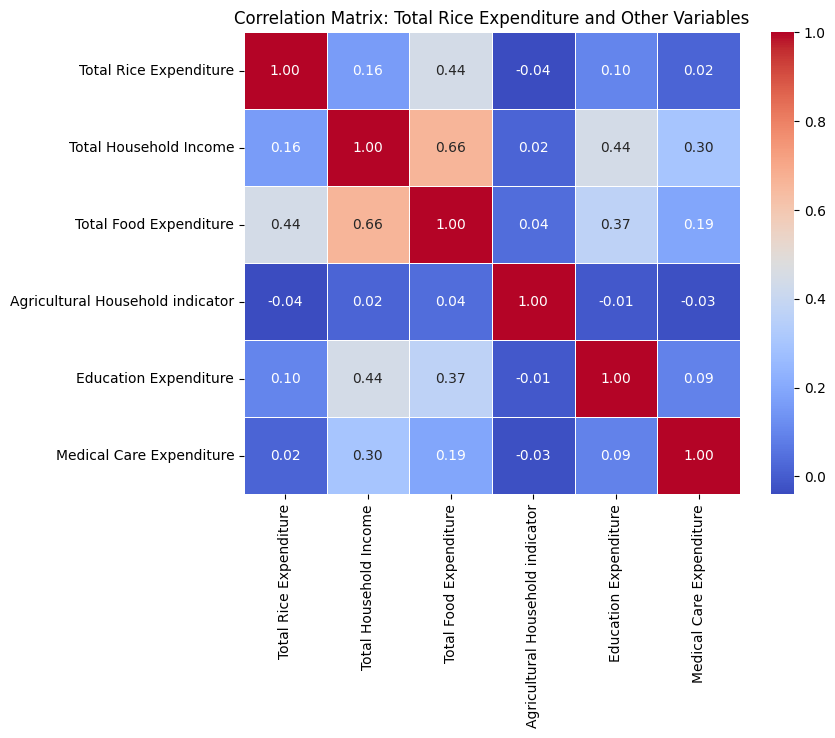

In [28]:
plt.figure(figsize=(8, 6))
sns.heatmap(rice_corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

plt.title("Correlation Matrix: Total Rice Expenditure and Other Variables")
plt.show()

### Insight 14:

### The correlation analysis reveals several key insights about factors associated with household spending on rice in the Philippines:

- <b>Food Expenditure (0.44):</b> There is a moderate positive correlation between Total Rice Expenditure and Total Food Expenditure, meaning households that spend more on food overall also tend to allocate more to rice. This makes sense as rice is a staple food and a major component of overall food costs.
- <b>Agricultural Household Indicator (-0.04):</b> There is a slight negative correlation with the Agricultural Household indicator, meaning agricultural households may spend less on rice, possibly because they grow their own rice or have easier access to rice from local sources.
- <b>Education and Medical Care Expenditure (0.10 and 0.02):</b> Very weak correlations with Education Expenditure and Medical Care Expenditure imply that spending on rice is not strongly influenced by how much households allocate to other areas like education or healthcare.

WAG MO TO IDEDELETE EXPLANATION KO TO

Food Spending (0.44): Households that spend more on food also spend more on rice. This makes sense since rice is a major part of food costs.

Income (0.16): Rice spending isn't strongly affected by income, meaning people spend roughly the same amount on rice, regardless of how much they earn.

Agricultural Households (-0.04): Households that farm their own rice tend to spend less on it, likely because they grow their own.

Education & Medical Spending (0.10 and 0.02): Spending on rice isn't much influenced by how much is spent on education or medical care.

### Q15: How does household income relate to overall food expenditure?

In [29]:
# Group by region and calculate average education expenditure
avg_education_exp = income.groupby("Region")["Education Expenditure"].mean().round(2)

# Identify the region with the highest education expenditure
top_education_region = avg_education_exp.idxmax()
top_education_value = avg_education_exp.max()

print(f"The region that spends the most on education on average is {top_education_region} with an average of ₱{top_education_value}.")

The region that spends the most on education on average is NCR with an average of ₱12021.56.


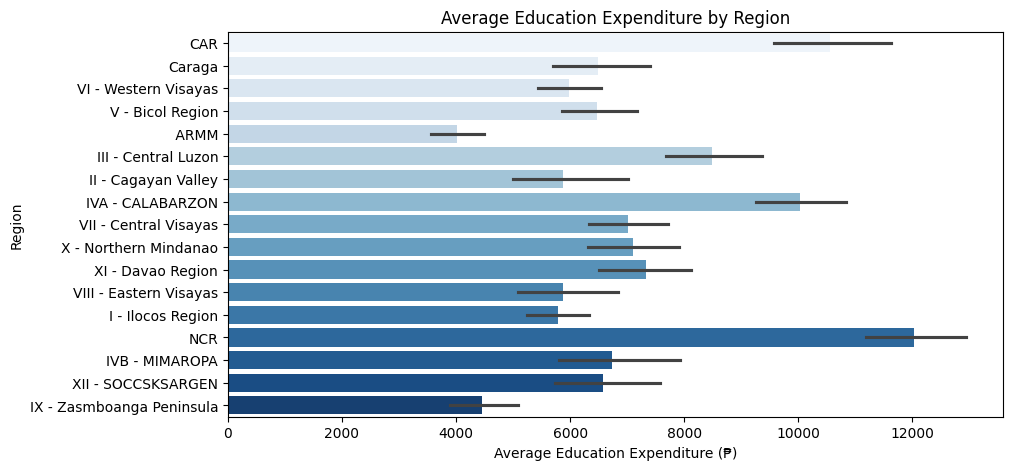

In [30]:
plt.figure(figsize=(10, 5))

sns.barplot(y=income["Region"], x=income["Education Expenditure"], palette="Blues")

plt.ylabel("Region")
plt.xlabel("Average Education Expenditure (₱)")
plt.title("Average Education Expenditure by Region")

plt.show()

In [31]:
# Select variables to correlate with appliance ownership
appliance_correlation_vars = [
    "Total Household Income",
    "Number of Refrigerator/Freezer",
    "Number of Washing Machine",
    "Number of Airconditioner",
    "Number of Personal Computer",
    "Number of Stove with Oven/Gas Range"
]

# Compute correlation matrix
appliance_corr = income[appliance_correlation_vars].corr().round(2)

# Print correlation of income with appliance ownership
print("Correlation with Appliance Ownership:")
print(appliance_corr["Total Household Income"].sort_values(ascending=False))


Correlation with Appliance Ownership:
Total Household Income                 1.00
Number of Personal Computer            0.56
Number of Airconditioner               0.55
Number of Refrigerator/Freezer         0.47
Number of Washing Machine              0.44
Number of Stove with Oven/Gas Range    0.38
Name: Total Household Income, dtype: float64


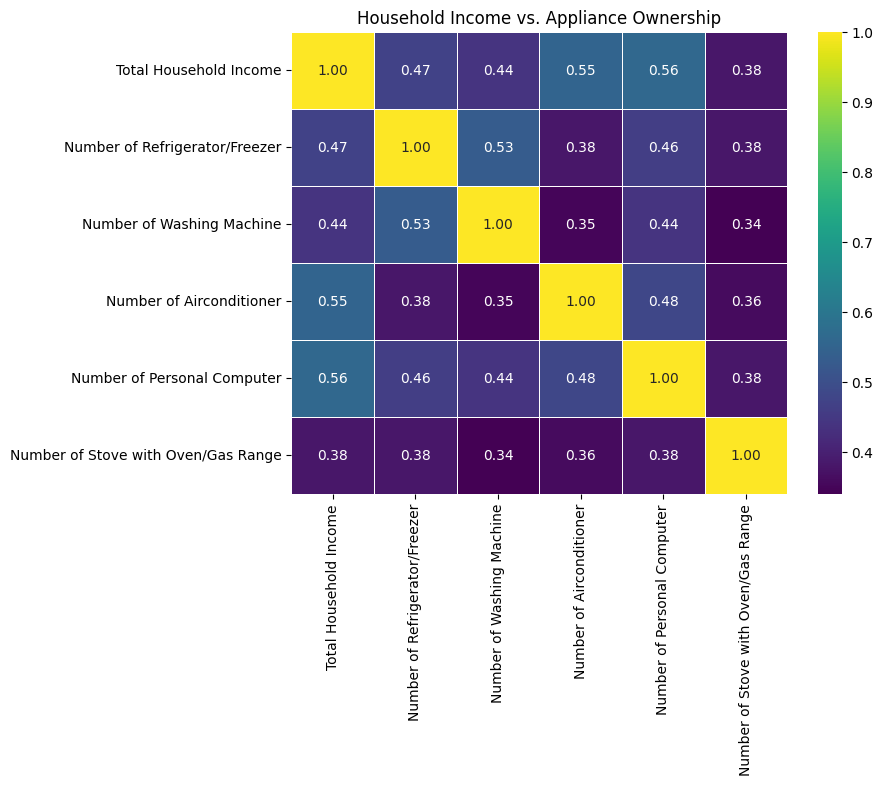

In [32]:
plt.figure(figsize=(8, 6))
sns.heatmap(appliance_corr, annot=True, cmap="viridis", fmt=".2f", linewidths=0.5)

plt.title("Household Income vs. Appliance Ownership")
plt.show()

### Insight 15:

### The correlation analysis between Total Household Income and Appliance Ownership reveals the following key findings:

- <b>Personal Computers and Household Income have the strongest positive correlation (0.56).</b> This suggests that higher-income households are more likely to own personal computers. This could indicate that wealthier households tend to invest more in technology for personal or professional use.

- <b>Air Conditioners and Household Income also show a strong positive correlation (0.55),</b> meaning that households with higher incomes are more likely to own air conditioners, which could be linked to better living standards and comfort in warmer climates.

- <b>Refrigerators/Freezers and Washing Machines show moderate positive correlations (0.47 and 0.44, respectively).</b> Higher-income households tend to own these essential household appliances, which are indicative of higher standards of living and the ability to afford these convenience items.

- <b>Stoves with Oven/Gas Ranges exhibit a weaker correlation (0.38) with household income,</b> suggesting that stove ownership is less influenced by income compared to other appliances like computers or air conditioners. This could imply that stoves are considered more of a basic necessity for most households, regardless of income.

### Q16. Which region has the highest average total household income? 

In [33]:
avg_income_per_region = income.groupby("Region")["Total Household Income"].mean().to_frame()
avg_income_per_region.columns = ["Average Income"]
avg_income_per_region = avg_income_per_region.sort_values(by="Average Income", ascending=False)

print("Regions ranked by highest average household income:")
print(avg_income_per_region)

Regions ranked by highest average household income:
                           Average Income
Region                                   
NCR                         420861.861501
IVA - CALABARZON            303360.536040
III - Central Luzon         292965.181650
CAR                         269540.484638
XI - Davao Region           238115.891251
I - Ilocos Region           238110.084327
II - Cagayan Valley         236778.221721
VII - Central Visayas       234909.314050
VI - Western Visayas        220481.260260
IVB - MIMAROPA              216685.124900
X - Northern Mindanao       214057.779544
Caraga                      196907.376543
VIII - Eastern Visayas      196736.581087
IX - Zasmboanga Peninsula   191000.908277
V - Bicol Region            186105.492718
XII - SOCCSKSARGEN          182984.802545
 ARMM                       134746.817616


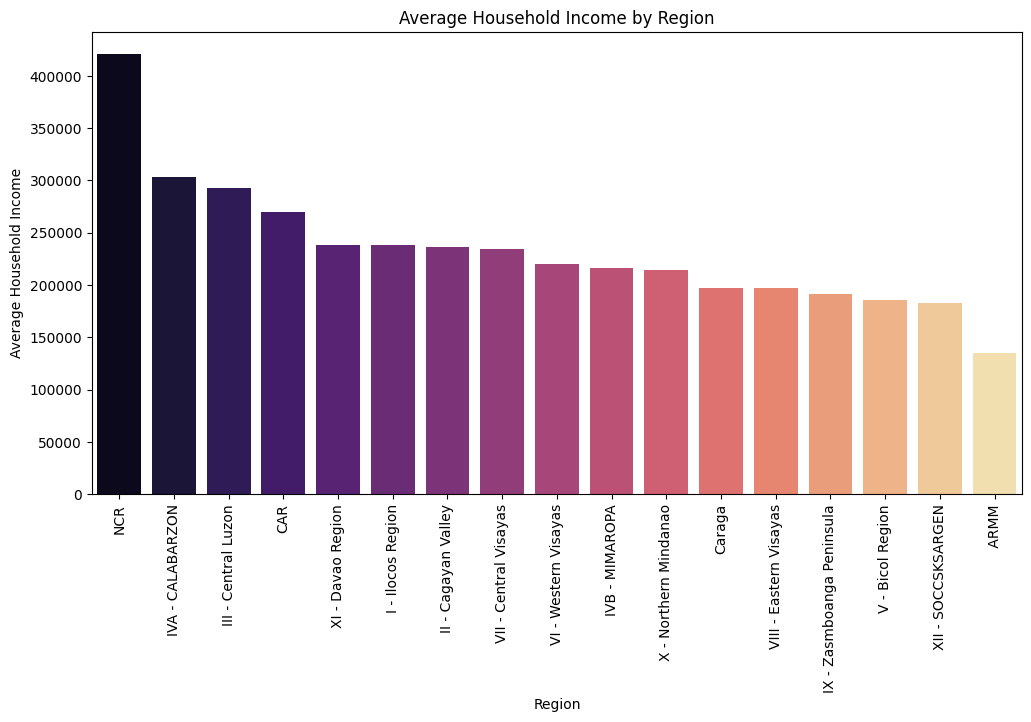

In [34]:
plt.figure(figsize=(12, 6))
sns.barplot(x="Region", y="Average Income", data=avg_income_per_region, palette="magma")

plt.xticks(rotation=90)
plt.xlabel("Region")
plt.ylabel("Average Household Income")
plt.title("Average Household Income by Region")

plt.show()

<p> <b> Insight 16: </b> 

The <b>National Capital Region (NCR)</b> has the highest average household income at ₱420,861.86, due to its status as the country's economic center. Other high-income regions include <b>CALABARZON, Central Luzon, and CAR</b>, which have strong industrial and agricultural activities. In contrast, ARMM has the lowest average income at ₱134,746.82, reflecting fewer economic opportunities.</p>

### Q17: How does rice expenditure compare between agricultural and non-agricultural households?

In [35]:
# Group by agricultural indicator and calculate the average rice expenditure
avg_rice_expenditure = income.groupby("Agricultural Household indicator", as_index=False)["Total Rice Expenditure"].mean()
avg_rice_expenditure.columns = ["Agricultural Household indicator", "Average Rice Expenditure"]

print("Average rice expenditure for agricultural vs. non-agricultural households:")
print(avg_rice_expenditure)

Average rice expenditure for agricultural vs. non-agricultural households:
   Agricultural Household indicator  Average Rice Expenditure
0                                 0              18396.853092
1                                 1              18304.770681
2                                 2              16695.244118


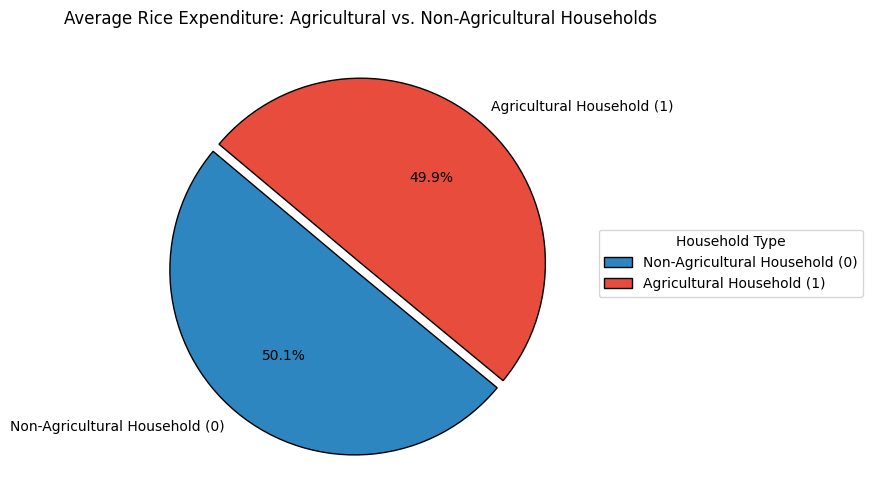

In [36]:
filtered_data = avg_rice_expenditure[avg_rice_expenditure["Agricultural Household indicator"].isin([0, 1])]

sizes = filtered_data["Average Rice Expenditure"]
labels = [ "Non-Agricultural Household (0)", "Agricultural Household (1)"]

colors = ["#2E86C1", "#E74C3C"]
explode = [0.05, 0] 

plt.figure(figsize=(6, 6))
wedges, texts, autotexts = plt.pie( sizes,labels=labels, colors=colors, startangle=140, explode=explode, autopct="%1.1f%%",wedgeprops={"edgecolor": "black"})

plt.legend(wedges, labels, title="Household Type", loc="center left", bbox_to_anchor=(1, 0.5))
plt.title("Average Rice Expenditure: Agricultural vs. Non-Agricultural Households", fontsize=12)

plt.show()

### Insight 17: 

Agricultural households with an indicator of 0 (likely non-agricultural) have the highest average rice expenditure at ₱18,396.85. Households with an indicator of 1 (likely agricultural) spend slightly less on average at ₱18,304.77, while those with an indicator of 2 (possibly mixed or another category) have the lowest average rice expenditure at ₱16,695.24.

### Q18: Which main source of income is associated with the highest average household income? 

In [37]:
avg_income_source = income.groupby("Main Source of Income", as_index=False)["Total Household Income"].mean()
avg_income_source.columns = ["Main Source of Income", "Average Income"]
avg_income_source = avg_income_source.sort_values(by="Average Income", ascending=False)

print("Main source of income associated with the highest average household income:")
print(avg_income_source)

Main source of income associated with the highest average household income:
        Main Source of Income  Average Income
2               Wage/Salaries   267414.952080
1     Other sources of Income   242638.827243
0  Enterpreneurial Activities   213484.383721


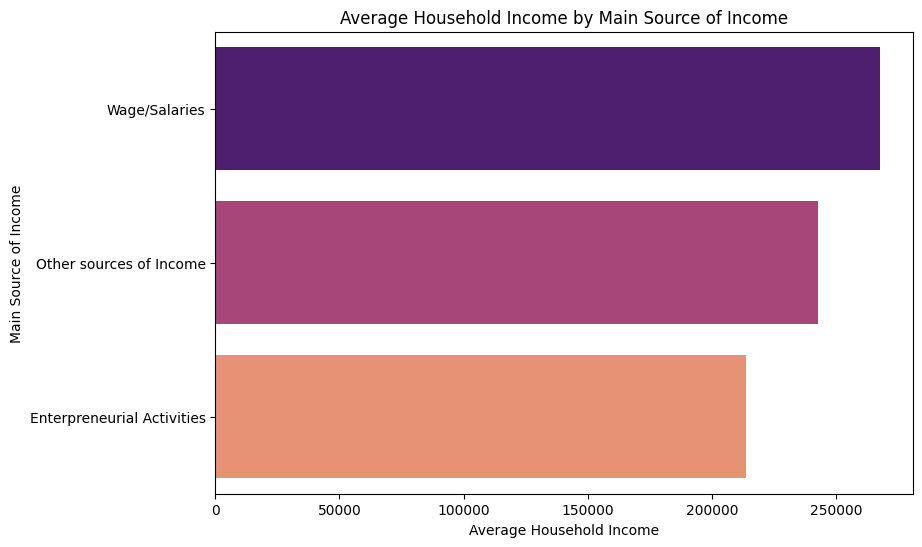

In [38]:
plt.figure(figsize=(9, 6))
sns.barplot(y="Main Source of Income", x="Average Income", data=avg_income_source, palette="magma")

plt.xlabel("Average Household Income")
plt.ylabel("Main Source of Income")
plt.title("Average Household Income by Main Source of Income")

plt.show()

<p> <b> Insight 18: </b> 
    
The main source of income associated with the highest average household income is <b>Wage/Salaries</b>, with an average income of ₱267,414.95. This indicates that households primarily relying on formal employment tend to have higher earnings compared to other income sources.

Following this, households with Other sources of Income have an average income of ₱242,638.83, while those primarily engaged in Entrepreneurial Activities have a lower average income of ₱213,484.38.

</p>

### Q19: How does the main source of income influence the average number of major electronic appliances owned by households?

In [39]:
# Create a new column that sums the number of major electronic appliances owned
income['Total Electronics'] = income["Number of Refrigerator/Freezer"] + income["Number of Washing Machine"] + income["Number of Airconditioner"]

# Group by main source of income and calculate the average number of electronics owned
avg_electronics_income_source = income.groupby("Main Source of Income")["Total Electronics"].mean().reset_index()

# Sort by the average number of electronics owned in descending order
avg_electronics_income_source_sorted = avg_electronics_income_source.sort_values(by="Total Electronics", ascending=False)

print(avg_electronics_income_source_sorted)


        Main Source of Income  Total Electronics
1     Other sources of Income           1.030085
2               Wage/Salaries           0.839219
0  Enterpreneurial Activities           0.657267


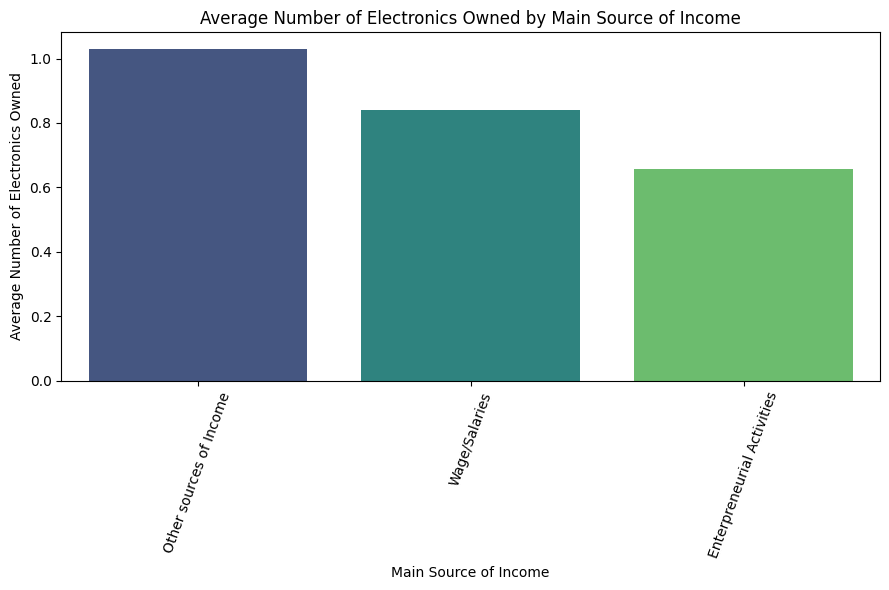

In [40]:
plt.figure(figsize=(9, 6))

sns.barplot(x="Main Source of Income", y="Total Electronics", data=avg_electronics_income_source_sorted, palette="viridis")

plt.xticks(rotation=70) 
plt.xlabel("Main Source of Income")
plt.ylabel("Average Number of Electronics Owned")
plt.title("Average Number of Electronics Owned by Main Source of Income")
plt.tight_layout()

plt.show()

<p> <b> Insight 19: </b> 

Base on the analysis, we can observe that households with "Other sources of Income" tend to own the highest average number of electronic appliances (such as refrigerators, washing machines, and air conditioners) with an average of 1.03 appliances per household. This could suggest that households relying on other income sources may have more disposable income or a different spending pattern that allows them to invest in more appliances.

On the other hand, households with "Wage/Salaries" as their main income source own an average of 0.84 electronic appliances, indicating that wage earners might be more cautious with spending or have a more limited budget for non-essential goods.

Households with "Entrepreneurial Activities" as their main source of income own the fewest appliances, with an average of 0.66 appliances. This could reflect the challenges entrepreneurs face in terms of fluctuating income, which may limit their ability to spend on durable goods like electronics.

<p>

### Q20: Which region has the highest number of cars owned? 

In [41]:
# Group by region and sum the total number of cars owned
total_cars_per_region = income.groupby('Region')['Number of Car, Jeep, Van'].sum().reset_index()

# Sort by total cars in descending order
total_cars_per_region_sorted = total_cars_per_region.sort_values(by="Number of Car, Jeep, Van", ascending=False)

print(total_cars_per_region_sorted)

                       Region  Number of Car, Jeep, Van
9                         NCR                       626
6            IVA - CALABARZON                       462
5         III - Central Luzon                       347
1                         CAR                       237
3           I - Ilocos Region                       211
12      VII - Central Visayas                       195
11       VI - Western Visayas                       186
15          XI - Davao Region                       185
4         II - Cagayan Valley                       169
14      X - Northern Mindanao                       137
16         XII - SOCCSKSARGEN                       130
2                      Caraga                       119
13     VIII - Eastern Visayas                       102
10           V - Bicol Region                        89
8   IX - Zasmboanga Peninsula                        81
7              IVB - MIMAROPA                        69
0                        ARMM                   

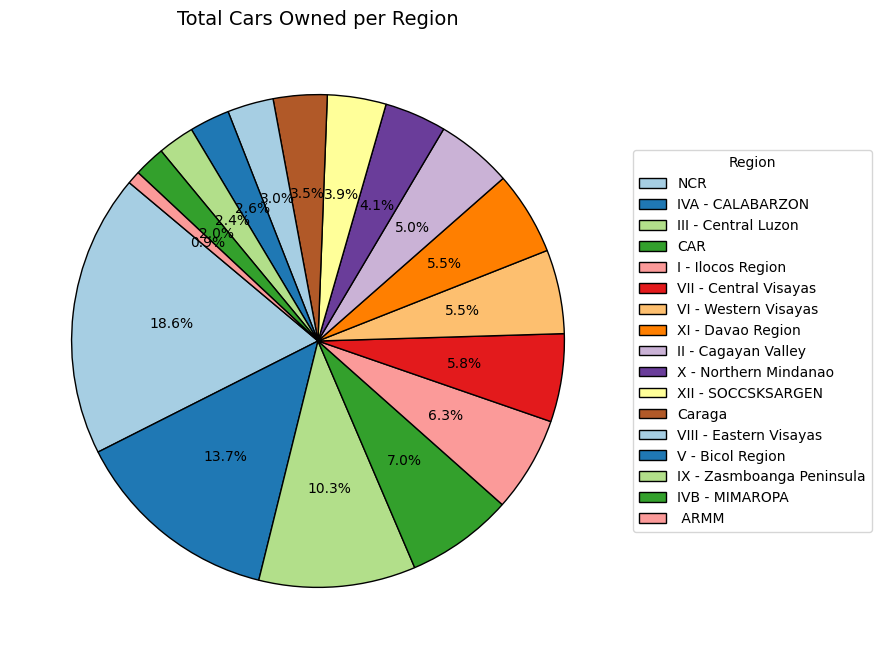

In [42]:
sizes = total_cars_per_region_sorted["Number of Car, Jeep, Van"]
labels = total_cars_per_region_sorted["Region"]

colors = plt.cm.Paired.colors[:len(labels)] 
plt.figure(figsize=(8, 8))
wedges, texts, autotexts = plt.pie(sizes, colors=colors, autopct="%1.1f%%", startangle=140, wedgeprops={"edgecolor": "black"})

plt.legend(wedges, labels, title="Region", loc="center left", bbox_to_anchor=(1, 0.5))
plt.title("Total Cars Owned per Region", fontsize=14)

plt.show()

<p> <b> Insight 20: </b> 

### **Insight:**

The **National Capital Region (NCR)** has the highest number of cars, with **626 cars** recorded. This makes sense, as NCR is the economic and political center of the country, with a higher population density, greater wealth, and more demand for personal transportation.

Other regions with a relatively high number of cars include **CALABARZON (462 cars)** and **Central Luzon (347 cars)**. These regions have well-developed infrastructures and are home to many businesses and industrial activities, making car ownership more common.

In contrast, regions like **ARMM** have the lowest number of cars, with only **29 cars**. This could indicate lower economic activity, fewer resources for personal transportation, and more reliance on public transportation.

This analysis shows that more developed and economically active regions tend to have more vehicles per household, while less developed or rural regions have fewer cars, possibly due to economic constraints or reliance on other transportation methods.

</p>